# AP 155 Lab Exercise
---
## Exercise 3: Evaluating polynomials (Horner's rule)

_Instructions_: 
- **Report figure (Problem 2):** Create a $2 \times 3$ grid of subplots comparing evaluations of the rational function $r(x)$, see Eq. (4):
    - Columns (3 Methods): Naive method (using direct powers), Horner's method, Rewritten form $s(x)$
    - Rows (2 values of $x$-points) $x= 1.606 + 2^{-52}i$ and $2.400 + 2^{-52}i$ where $i\in[0,800]$.

- **Report discussion (Problem 2):** Two questions:
    - Using your figure as reference, compare the rounding error patterns and output stability of Horner's method, naive power evaluation, and rewritten form $s(x)$. Are rounding errors random? Discuss the discrepancies and origin.
    - Explain why algebraically identical expressions (such as Eq. (4) and Eq. (5)) produce different numerical values when implemented in floating-point arithmetic.

  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Baculo, Ezira Lojelle
- _Student No._: 2024-11845
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

In [5]:
# use `fig, axs = plt.subplots(...)` to generate your figure with subplots
# then call fig to show your image instead of using markdown
# Your goal is to replicate this... feel free to adjust the visuals

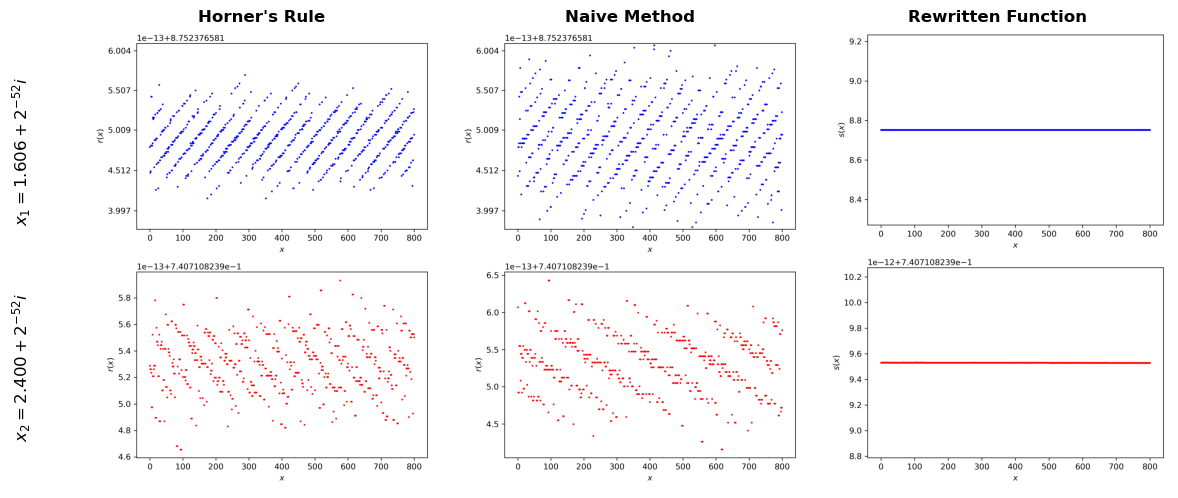

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axs = plt.subplots(1, 3, figsize=(12, 5))

images = [
    ("Horner_Plot.png", "Horner's Rule"),
    ("Naive_Plot.png", "Naive Method"),
    ("Rewritten_Plot.png", "Rewritten Function")
]

for ax, (filename, title) in zip(axs, images):
    img = mpimg.imread(filename)
    ax.imshow(img)
    ax.set_title(title, fontweight='bold')
    ax.axis("off")

axs[0].axis("on")                         # Turn axis back on for the first plot
axs[0].set_xticks([])                      # Remove x ticks
axs[0].set_yticks([])                      # Remove y ticks
for spine in axs[0].spines.values():       # Hide the bounding box borders
    spine.set_visible(False)

axs[0].set_ylabel(
    r"$x_2 = 2.400 + 2^{-52}i$             $x_1 = 1.606 + 2^{-52}i$", 
    rotation=90, 
    labelpad=50,                           
    verticalalignment='center',
    fontsize=12
)

plt.tight_layout()
plt.show()

#### Figure 2.3: Comparison of Rational Function Evaluation Methods

In this figure as a $2 \times 3$ grid of subplots, the evaluation of the rational function $r(x)$ and its rewritten form $s(x)$ using three methods (Naive, Horner's Rule, and Rewritten Function) for two different ranges of $x$ values is shown. The behavior for $x_1 = 1.606 + 2^{-52}i$ is shown in the top row, and the results for $x_2 = 2.400 + 2^{-52}i$, where $i \in [0, 800]$, are shown in the bottom row. To illustrate the rounding error patterns typical of each method and $x$ range, the `ylim` bounds are truncated.

### Report discussion

(1) For $x_1$ (near 1.606), both the Naive method and Horner's rule exhibit significant, patterned erratic behavior, showing a significant loss of precision caused by catastrophic cancellation in floating-point operations. The structured errors suggest that rounding errors are systematic rather than random and can propagate throughout the computation. In contrast, the rewritten function, $s(x)$, yields a remarkably stable, nearly flat line for $x_1$, indicating low rounding error and high output stability. This implies that the rewritten form avoids the conditions that result in catastrophic cancellation.

Similarly, for $x_2$ (near 2.400), the Naive method and Horner's rule exhibit significant erratic behavior, albeit with a slightly different pattern. The rewritten function, $s(x)$, remains stable and produces a flat line. These discrepancies primarily result from catastrophic cancellation, which occurs when subtracting two nearly equal large numbers and results in the loss of significant digits and the amplification of errors in the less significant digits.

(2) Algebraically identical expressions can result in different numerical values in floating-point arithmetic due to its finite precision. Different algebraic forms correspond to different floating-point operation sequences, despite their mathematical equivalency. Rounding errors are naturally amplified by operations such as subtraction of nearly equal large numbers (as in the original `r(x)` for some $x$ values), also known as catastrophic cancellation. The rewritten form, $s(x)$, is designed to avoid such problematic operations, thereby minimizing the accumulation of rounding errors. Even though the underlying mathematical function remains the same, restructuring the expression results in a sequence of operations that is less susceptible to the limitations of finite-precision arithmetic, producing noticeably more accurate and stable results.

### Other comments

- I did ask for help with my friends in this (especially in the plotting of the figures and the truncation), but I thought it was not as tricky as last week's exercise.

---
## Section 2: Code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

**NOTE: Only use 64-bit precision floating-point number data type.**

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's Rule*. Take a polynomial of degree $n-1$:

$$ P(x) = p_0 + p_1x + p_2x^2 + p_3x^3 + ... + p_{n-1}x^{n-1}. \tag{1} $$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e. from left to right. Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x\times x\times ... \times x$ (where there are $i-1$ multiplications). Thus, this way of approaching the problem corresponds to
$$ 1 + 2 + ... + n-2 = \frac{(n-1)(n-2)}{2} \tag{2}$$
multiplications, from $x^2$ all the way up to $x^{n-1}$. If we write the polynomial: 
$$ P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + ... + x(p_{n-2} + xp_{n-1})...))) \tag{3}$$

then we can get away with only $n-1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). Write a function that takes in a list containing the $p_i$'s, say `coeffs`  and the point $x$ and evaluates the value of $P(x)$ in a new way, i.e., from right to left. Apply the previous two functions to the (admittedly artificial) case of:
`coeffs=[(-11)**i for i in reversed(range(8))]` and $x=11.01$. Observe any discrepancy and discuss its origin.

In [3]:
coeffs=[(-11)**i for i in reversed(range(8))]   
x = 11.01

(a) Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e. from left to right... see Eq. (1).

In [4]:
def eval_naive(coeffsList, x):
    """
    Evaluate naively from left to right.
    """
    result = 0.0
    for i, p_i in enumerate(coeffsList):
        result += p_i * (x ** i)
    return result

eval_naive(coeffs, 11.01)

71056.02362162992

(b) Write a function that takes in a list containing the $p_i$'s, say `coeffs`  and the point $x$ and evaluates the value of $P(x)$ in a new way, i.e., from right to left... see Eq. (3).

In [5]:
def eval_horner(coeffsList, x):
    """
    Using Horner's rule from right to left.
    """
    result = 0.0 
    for coeff in reversed(coeffsList):
        result = result * x + coeff
    return result

eval_horner(coeffs, 11.01)

71056.02362163365

#### Problem 1 code summary

This script applies Horner's rule and a naive left-to-right method for polynomial evaluation. The `eval_naive` function, which represents a simple but less effective approach, computes each term $p_i x^i$ directly and sums them up. By iterating through coefficients in reverse, however, `eval_horner` makes use of Horner's rule, significantly reducing the number of multiplications and enhancing numerical stability by reducing error accumulation.

---

### Problem 2: Using the previously-made functions. (Gezerlis Problem 2.12)

**NOTE: Only use 64-bit precision floating-point number data type.**

This problem studies the rational function introduced in the main text, Eq. (2.53) [Gezerlis].

$$ r(x) = \frac{4x^4 - 59x^3 + 324 x^2 - 751x + 622}{x^4 - 14x^3 + 72x^2 - 151x + 112} \tag{4}$$

(a) Apply Horner’s rule twice (once for the numerator and once for the denominator) to produce two plots, one for $x = 1.606 + 2^{−52}i$ and one for $x = 2.400 + 2^{−52}i$ where $i\in[0,800]$ in steps of $1$. Your results should look like Fig. 2.3 in the book (see below). 
![](./figures/gezerlis_fig23.png)

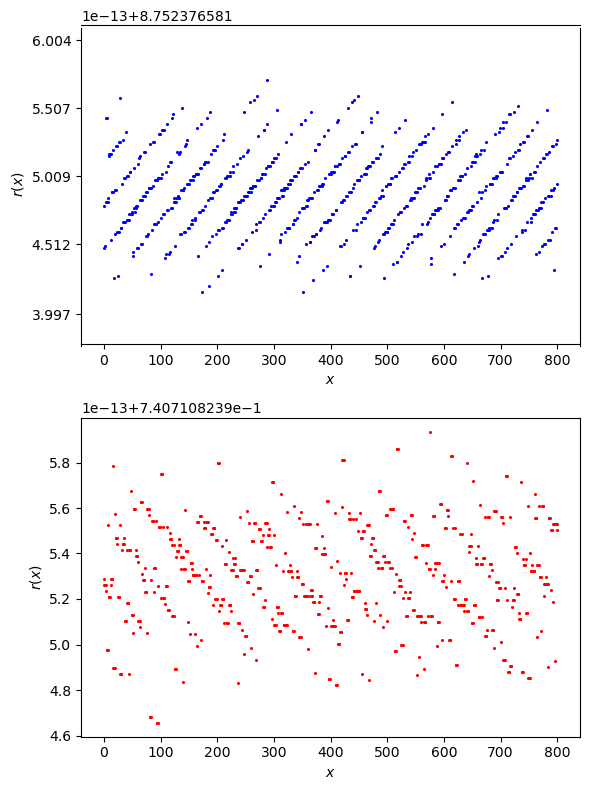

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# take note of the ordering of the coefficients
# note that Eq. (1) is written in increasing powers of x from left to right
# while Eq. (4) is written in decreasing powers of x from left to right

num_coeffs = [622, -751, 324, -59, 4]
den_coeffs = [112, -151, 72, -14, 1]

# try to learn the syntax in generating subplots as they are very flexible
# plt.subplots()

def horner(coeffs, x):
  """
  Evaluates a polynomial with coefficients ordered by increasing powers using Horner's rule.
  """
  result = np.zeros_like(x, dtype=np.float64)
  for c in reversed(coeffs):
    result = result * x + c
  return result

def r(x):
  """
  Evaluates the rational function r(x) using Horner's rule.
  """
  return horner(num_coeffs, x) / horner(den_coeffs, x)

# Domain setup in 64-bit precision
i = np.arange(801, dtype=np.float64)
dx = np.float64(2**-52)

x1 = np.float64(1.606) + dx * i
x2 = np.float64(2.400) + dx * i

r1 = r(x1)
r2 = r(x2)

# Generate Figure 2.3 (Part A: 2 Subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# you may need to truncate ylim bounds to see the pattern
ymin, ymax = np.min(r1), np.max(r1)
padding = (ymax - ymin) * 0.25
ax1.set_ylim(ymin - padding, ymax + padding)

ax1.scatter(i, r1, color="blue", s=1.5)
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$r(x)$")

ax2.scatter(i, r2, color="red", s=1.5)
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$r(x)$")

plt.tight_layout()
plt.savefig("Horner_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

(b) Create a new Python function that codes up the following expression:
$$ s(x)= 4− \frac{3(x−2)[(x−5)^2 + 4]}{x + (x−2)^2[(x−5)^2 + 3]} \tag{5}$$
which is a rewritten version of our rational function. Apply this new function for
the previous two plots and compare the rounding error pattern, size, etc.

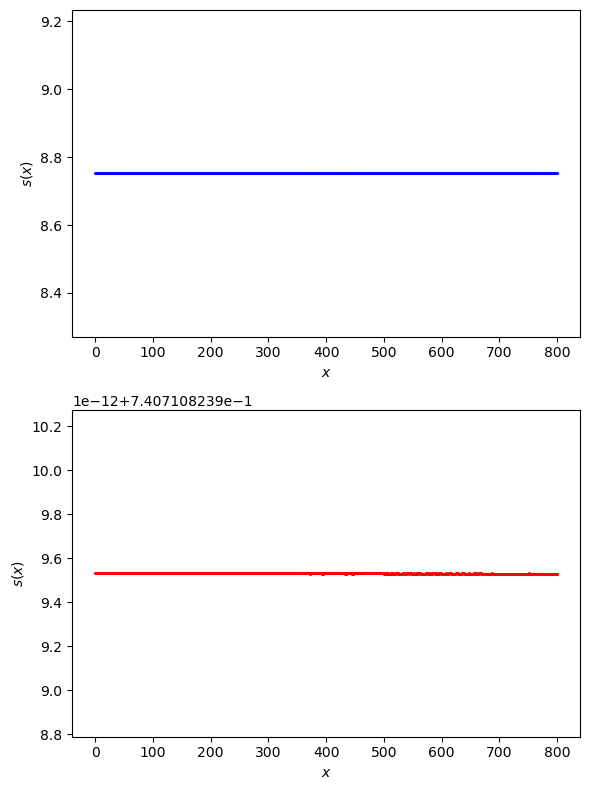

In [7]:
def s_x(x):
  """
  Evaluates the rewritten rational function s(x) as defined in Eq. (5).
  Ensures calculations are performed with 64-bit precision.
  """
  # Ensure x is float64 for all calculations
  x = np.asarray(x, dtype=np.float64)

  # Intermediate terms for clarity and potential error analysis
  x_minus_2 = x - np.float64(2.0)
  x_minus_5 = x - np.float64(5.0)
  x_minus_5_squared = x_minus_5**np.float64(2.0)

  numerator_term = np.float64(3.0) * x_minus_2 * (x_minus_5_squared + np.float64(4.0))
  denominator_term = x + (x_minus_2**np.float64(2.0)) * (x_minus_5_squared + np.float64(3.0))

  return np.float64(4.0) - (numerator_term / denominator_term)

# Apply the new function to x1 and x2 (x1 and x2 are already defined in the kernel state)
s1 = s_x(x1)
s2 = s_x(x2)

# Generate plots for s(x)
fig_s, (ax1_s, ax2_s) = plt.subplots(2, 1, figsize=(6, 8))

ax1_s.scatter(i, s1, color="blue", s=1.5)
ax1_s.set_xlabel(r"$x$")
ax1_s.set_ylabel(r"$s(x)$")

ax2_s.scatter(i, s2, color="red", s=1.5)
ax2_s.set_xlabel(r"$x$")
ax2_s.set_ylabel(r"$s(x)$")

plt.tight_layout()
plt.savefig("Rewritten_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

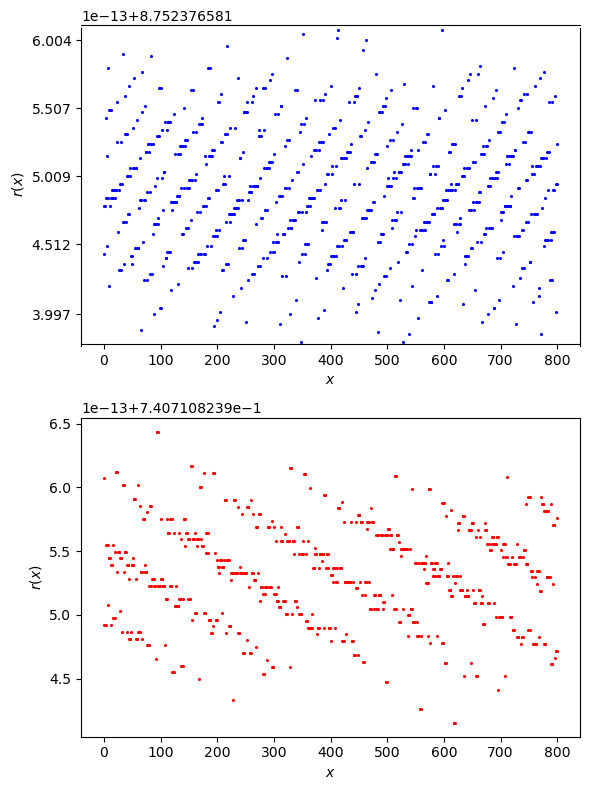

In [8]:
def horner_naive(coeffs, x):
  """
  Evaluates a polynomial with coefficients ordered by decreasing powers (e.g., p_n, p_{n-1}, ..., p_0)
  using a naive direct power calculation. Ensures 64-bit precision.
  """
  x = np.asarray(x, dtype=np.float64)
  result = np.zeros_like(x, dtype=np.float64)
  power = len(coeffs) - 1
  for coeff in coeffs:
    result += coeff * (x**power)
    power -= 1
  return result

def r_naive(x):
  """
  Evaluates the rational function r(x) using naive polynomial evaluation for numerator and denominator.
  """
  return horner_naive(num_coeffs_naive_order, x) / horner_naive(den_coeffs_naive_order, x)

coeffs = [112, -151, 72, -14, 1]
num_coeffs_naive_order = [4, -59, 324, -751, 622] 
den_coeffs_naive_order = [1, -14, 72, -151, 112] 

num_coeffs_naive_order = [4, -59, 324, -751, 622] 
den_coeffs_naive_order = [1, -14, 72, -151, 112] 

# Apply the naive function to x1 and x2
r1_naive = r_naive(x1)
r2_naive = r_naive(x2)

# Generate plots for naive r(x)
fig_naive, (ax1_naive, ax2_naive) = plt.subplots(2, 1, figsize=(6, 8))

ymin, ymax = np.min(r1), np.max(r1)
padding = (ymax - ymin) * 0.25
ax1_naive.set_ylim(ymin - padding, ymax + padding)

ax1_naive.scatter(i, r1_naive, color="blue", s=1.5)
ax1_naive.set_xlabel(r"$x$")
ax1_naive.set_ylabel(r"$r(x)$")

ax2_naive.scatter(i, r2_naive, color="red", s=1.5)
ax2_naive.set_xlabel(r"$x$")
ax2_naive.set_ylabel(r"$r(x)$")

plt.tight_layout()
plt.savefig("Naive_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

#### Problem 2 code summary

Three methods are used in this section to implement and visualize the rational function r(x): a naive direct power evaluation, a rewritten algebraic form, and Horner's rule. For x values close to 1.606 and 2.400, the code creates separate plots for each method in addition to a combined 2x3 grid to compare their behavior. In order to effectively truncate the view and highlight the unique rounding error patterns and stability characteristics of each evaluation method, ylim bounds were carefully set for each subplot. 

---
## Section 3 (Notes)

In [6]:
import numpy as np

# initialize an array with an explicit float64 type
arr = np.array([1.5, 2.73, 3.14], dtype=np.float64)

# cast an existing integer array to float64
int_arr = np.array([1, 2, 3])
float_arr = int_arr.astype(np.float64)

### Representing real numbers

Python employs what are known as double-precision floating point numbers, also called doubles; their storage uses 64 bits in total. Doubles can represent:
$$ \pm 4.9\times10^{-324} \leftrightarrow \pm 1.8\times 10^{308} $$

In [1]:
# we can represent
print(4.9e-324)

# but not 
print(4.9e-325) # this number is too small for our 64bit machine

5e-324
0.0


In [2]:
# we can represent
print(1.8e307)

# but not 
print(1.8e308) # this number is too big for our 64bit machine

1.8e+307
inf


#### Overflow

In [3]:
# exhibits overflow

large = 2.**1021
for i in range(3):
    large *= 2
    print(i, large)

0 4.49423283715579e+307
1 8.98846567431158e+307
2 inf


In [4]:
print(8.98846567431158e+307*1.999999999999999)
print(8.98846567431158e+307*2.)

1.797693134862315e+308
inf


#### Underflow

In [5]:
from math import sqrt

def f(x, nmax=100):
    for i in range(nmax):
        x = sqrt(x)
    for i in range(nmax):
        x = x**2
    return x

for xin in (5., 0.5):
    xout = f(xin)
    print(xin, xout)

5.0 1.0
0.5 0.0


In [232]:
xtilde = 1234567891234567.0
ytilde = 1234567891234566.0

xtilde**2 - ytilde**2 

# this has catastrophic cancellation 
# note you're making the numbers very large (losing precision)
# then subtracting them (propagating lost precision)

2533274790395904.0

In [235]:
# but if you convert into integers first, the result will be exact
# integers have infinite machine precision!

int(xtilde)**2 - int(ytilde)**2 

2469135782469133

In [236]:
# rewritten equivalent and integer
(int(xtilde) - int(ytilde))*(int(xtilde) + int(ytilde)) 

2469135782469133

In [252]:
small = 1/2**50
for i in range(3):
    small /= 2
    print(i, 1 + small, small)

0 1.0000000000000004 4.440892098500626e-16
1 1.0000000000000002 2.220446049250313e-16
2 1.0 1.1102230246251565e-16


In [253]:
print(1. + 2.3e-16)
print(1. + 1.6e-16)
print(1. + 1.12e-16)
print(1. + 1.1e-16)

1.0000000000000002
1.0000000000000002
1.0000000000000002
1.0


In [259]:
0.5e-16+0.5

0.5

In [2]:
xt = 0.1 + 0.2
yt = 0.3
epsilon = 1.e-12
abs(xt-yt) < epsilon

True

In [4]:
xt = 12345678912.345
yt = 12345678912.346
epsilon = 1.e-12
abs(xt-yt) < epsilon

def findmax(x,y):
    return max(abs(x),abs(y))

abs(xt-yt)/findmax(xt,yt) < epsilon

True

In [13]:
# floating pt arithmetic is not associative

print((0.7 + 0.1) + 0.3)
print(0.7 + (0.1 + 0.3))

x=1e20
y=-1e20
z=1.0

print((x+y) + z)
print(x + (y+z))

1.0999999999999999
1.1
1.0
0.0


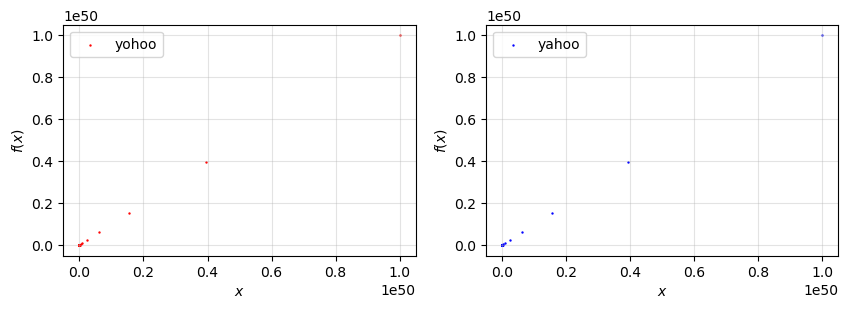

In [15]:
xlist = np.logspace(10, 50, 100)
ylist = xlist
ylist2 = xlist**2

fig, axs = plt.subplots(1,2, figsize=(10,3))
axs[0].scatter(xlist, ylist, s=0.5, c='r', label='yohoo')
axs[1].scatter(xlist, ylist, s=0.5, c='b', label='yahoo')
for ax in axs:
    ax.grid(True, alpha=0.35)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$f(x)$')
    ax.legend()
plt.show()